### Exercise Report for Course: Stochastic Simulation

0. Library Imports

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import geom
from scipy.stats.sampling import DiscreteAliasUrn
from scipy.stats import chisquare
import time
import random
import math
import simpy
import pandas as pd
from collections import Counter

#### Day 5 Exercises
1. Metropolis - Hasting Algo

In [6]:
# Parameters: from exercise 4
M = 10  # Capacity
MEAN_SERVICE_TIME = [6, 8, 12]  # Mean service time, original time is 8 time units
LAMBDA_A = 1.0  # Arrival rate
TARGET_CUSTOMERS = 10_000  # Customers per simulation run
REPLICATIONS = 10  # Number of simulation runs for CI calculation
selected_time = 1  # Index for mean service time (0: 6, 1: 8, 2: 10)

A = LAMBDA_A * MEAN_SERVICE_TIME[selected_time]

# set the seed for reporducibility
np.random.seed(42)

def g(i, A):
    return A**i / math.factorial(i)


# Proposal function
def propose(x, m):
    if x == 0:
        return 0 if random.random() < 0.5 else 1
    elif x == m:
        return m if random.random() < 0.5 else m - 1
    else:
        return x + 1 if random.random() < 0.5 else x - 1


# acceptance ration function
def acceptance_ratio(x, y, A):
    return min(1.0, g(y, A) / g(x, A))


def metropolis_hastings(A, m, N, burn_in=1000):
    x = 0                      
    samples = []

    for t in range(N + burn_in):
        y = propose(x, m)
        alpha = acceptance_ratio(x, y, A)

        if random.random() < alpha:
            x = y

        if t >= burn_in:
            samples.append(x)

    # How many servers are busy?
    return samples


def true_probabilities(A, M):
    weights = [g(i, A) for i in range(M+1)]
    S = sum(weights)
    return [w / S for w in weights]

def chi_square_test(samples, probs):
    N = len(samples)
    m = len(probs) - 1

    # observed counts
    O = [0]*(m+1)
    for s in samples:
        O[s] += 1

    # expected counts
    E = [N * p for p in probs]

    # chi-square statistic
    chi2 = sum((O[i] - E[i])**2 / E[i] for i in range(m+1))

    return chi2


In [7]:
# Results
samples = metropolis_hastings(A, M, TARGET_CUSTOMERS, burn_in=1000)
probs = true_probabilities(A, M)
chi2 = chi_square_test(samples, probs)
p_value = stats.chi2.sf(chi2, df=M)

# Null hypothesis: MH samples follow the truncated Poisson
# Alternative hypothesis: The observed frequencies do not match the expected frequencies.

print(f"Chi-square statistic: {chi2:.4f}")
p_value = stats.chi2.sf(chi2, df=M)
print(f"p-value: {p_value:.4f}")
alpha = 0.05
if p_value < alpha:
    print("Reject null hypothesis")
else:
    print("Fail to reject null hypothesis")

# Check the reason why is the null hypothesis rejected
counts = Counter(samples)
probs = true_probabilities(A, M)

for i in range(M+1):
    O = counts.get(i, 0)
    E = len(samples) * probs[i]
    print(f"i={i:2d}, observed={O:6.0f}, expected={E:8.2f}")


# Note: Although the chi**2 test rejects the null hypothesis at α = 0.05, the observed and expected frequencies are extremely close.  
# In practical terms, the MH sampler correctly reproduces the truncated Poisson distribution.

Chi-square statistic: 114.1547
p-value: 0.0000
Reject null hypothesis
i= 0, observed=     5, expected=    4.11
i= 1, observed=    35, expected=   32.89
i= 2, observed=   145, expected=  131.57
i= 3, observed=   345, expected=  350.86
i= 4, observed=   607, expected=  701.72
i= 5, observed=  1039, expected= 1122.75
i= 6, observed=  1378, expected= 1497.00
i= 7, observed=  1579, expected= 1710.86
i= 8, observed=  1707, expected= 1710.86
i= 9, observed=  1680, expected= 1520.76
i=10, observed=  1480, expected= 1216.61


Part 2, A

In [8]:
def g_2d(i, j, A1, A2):
    if i < 0 or j < 0 or i + j > M:
        return 0.0
    return (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))


def propose_2d(i, j, M):
    moves = []
    # candidate neighbors
    candidates = [(i+1, j), (i-1, j), (i, j+1), (i, j-1)]
    for (u, v) in candidates:
        if u >= 0 and v >= 0 and u + v <= M:
            moves.append((u, v))
    if not moves:
        return (i, j)
    return random.choice(moves)


def acceptance_ratio_2d(i, j, u, v, A1, A2):
    num = g_2d(u, v, A1, A2)
    den = g_2d(i, j, A1, A2)
    if den == 0:
        return 1.0
    return min(1.0, num / den)


def metropolis_hastings_2d(A1, A2, M, N, burn_in=1000):
    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):
        u, v = propose_2d(i, j, M)
        alpha = acceptance_ratio_2d(i, j, u, v, A1, A2)

        if random.random() < alpha:
            i, j = u, v

        if t >= burn_in:
            samples.append((i, j))

    return samples


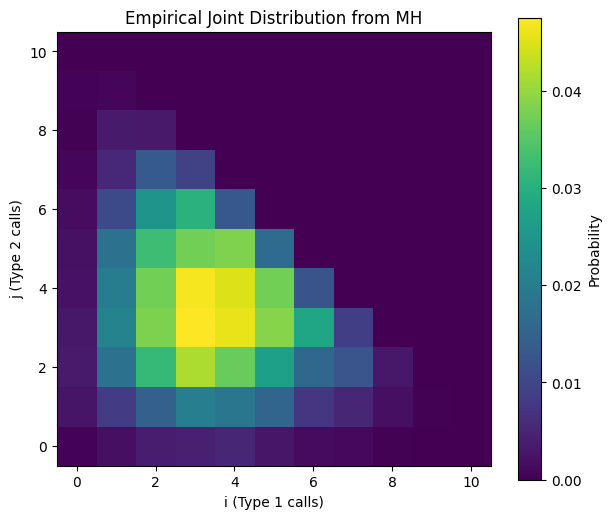

In [9]:
A1 = 4
A2 = 4
M = 10
N = 10_000

samples_2d = metropolis_hastings_2d(A1, A2, M, N)

def plot_heatmap(samples, M, title):
    grid = np.zeros((M+1, M+1))

    for (i, j) in samples:
        grid[i, j] += 1

    # Normalize to probabilities
    grid = grid / grid.sum()

    plt.figure(figsize=(7,6))
    plt.imshow(grid.T, origin='lower', cmap='viridis')
    plt.colorbar(label="Probability")
    plt.xlabel("i (Type 1 calls)")
    plt.ylabel("j (Type 2 calls)")
    plt.title(title)
    plt.show()


plot_heatmap(samples_2d, M, "Empirical Joint Distribution from MH")

Part 2, B

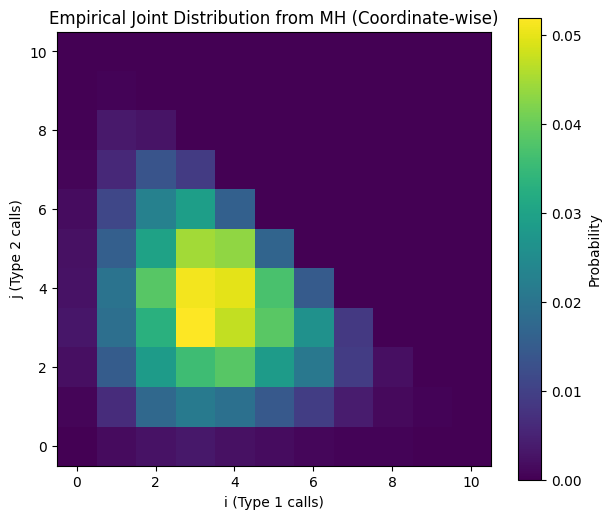

In [10]:
def g_2d(i, j, A1, A2, M):
    if i < 0 or j < 0 or i + j > M:
        return 0.0
    return (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))


def propose_i(i, j, M):
    moves = []
    if i + 1 + j <= M:
        moves.append(i + 1)
    if i - 1 >= 0:
        moves.append(i - 1)
    if not moves:
        return i
    return random.choice(moves)


def propose_j(i, j, M):
    moves = []
    if j + 1 + i <= M:
        moves.append(j + 1)
    if j - 1 >= 0:
        moves.append(j - 1)
    if not moves:
        return j
    return random.choice(moves)


def accept(i, j, new_i, new_j, A1, A2, M):
    num = g_2d(new_i, new_j, A1, A2, M)
    den = g_2d(i, j, A1, A2, M)
    return min(1.0, num / den)

def mh_coordinatewise(A1, A2, M, N, burn_in=1000):
    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):

        i_prop = propose_i(i, j, M)
        alpha_i = accept(i, j, i_prop, j, A1, A2, M)
        if random.random() < alpha_i:
            i = i_prop

        j_prop = propose_j(i, j, M)
        alpha_j = accept(i, j, i, j_prop, A1, A2, M)
        if random.random() < alpha_j:
            j = j_prop

        if t >= burn_in:
            samples.append((i, j))

    return samples


samples_coordinate = mh_coordinatewise(A1=4, A2=4, M=10, N=TARGET_CUSTOMERS, burn_in=1000)

plot_heatmap(samples_coordinate, M, "Empirical Joint Distribution from MH (Coordinate-wise)")

Part 2, C (Gibbs)

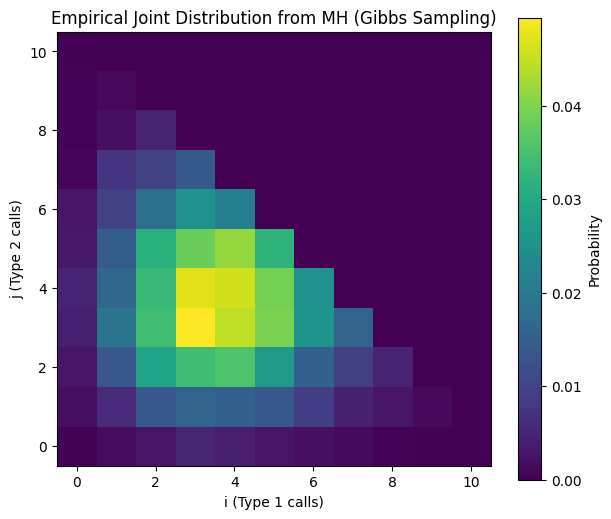

In [11]:
def sample_trunc_poisson_like(A, max_k):
    # unnormalized weights
    weights = [A**k / math.factorial(k) for k in range(max_k + 1)]
    S = sum(weights)
    probs = [w / S for w in weights]

    u = random.random()
    cumsum = 0.0
    for k, p in enumerate(probs):
        cumsum += p
        if u <= cumsum:
            return k
    return max_k


def gibbs_sampler(A1, A2, M, N, burn_in=1000):
    i, j = 0, 0
    samples = []

    for t in range(N + burn_in):

        max_i = M - j
        i = sample_trunc_poisson_like(A1, max_i)

        max_j = M - i
        j = sample_trunc_poisson_like(A2, max_j)

        if t >= burn_in:
            samples.append((i, j))

    return samples

samples_gibbs = gibbs_sampler(A1=4, A2=4, M=M, N=TARGET_CUSTOMERS, burn_in=1000)

plot_heatmap(samples_gibbs, M, "Empirical Joint Distribution from MH (Gibbs Sampling)")

### Part 2, Chi 2 Testing

In [12]:
def observed_counts(samples):
    return Counter(samples)

def true_joint(A1, A2, M):
    weights = {}
    total = 0.0
    for i in range(M+1):
        for j in range(M+1):
            if i + j <= M:
                w = (A1**i / math.factorial(i)) * (A2**j / math.factorial(j))
                weights[(i,j)] = w
                total += w
    # normalize
    for key in weights:
        weights[key] /= total
    return weights


def chi2_test_2d(samples, probs):
    N = len(samples)
    O = observed_counts(samples)

    chi2 = 0.0
    for (i,j), p in probs.items():
        E = N * p
        Oij = O.get((i,j), 0)
        chi2 += (Oij - E)**2 / E

    df = len(probs) - 1
    p_value = 1 - stats.chi2.cdf(chi2, df)
    return chi2, p_value, df


probs = true_joint(A1=4, A2=4, M=10)

for name, S in [
    ("Joint MH", samples_2d),
    ("Coordinate-wise MH", samples_coordinate),
    ("Gibbs", samples_gibbs)
]:
    chi2, pval, df = chi2_test_2d(S, probs)
    print(name, round(chi2, 4), round(pval, 4))
    if pval < 0.05:
        print("Reject null hypothesis")
    else:
        print("Fail to reject null hypothesis")

Joint MH 444.2522 0.0
Reject null hypothesis
Coordinate-wise MH 405.2889 0.0
Reject null hypothesis
Gibbs 69.8018 0.3194
Fail to reject null hypothesis


Part 3, A

In [13]:
rho = 0.5

mean = np.array([0.0, 0.0])
cov = np.array([
    [1.0,        rho],
    [rho,        1.0]])

def sample_xi_gamma():
    xi, gamma = np.random.multivariate_normal(mean, cov)
    return xi, gamma

# Transformation
def sample_theta_psi():
    xi, gamma = sample_xi_gamma()
    theta = np.exp(xi)
    psi   = np.exp(gamma)
    return theta, psi



Part 3, B

In [14]:
n = 10

theta, psi = sample_theta_psi()

X = np.random.normal(loc=theta, scale=np.sqrt(psi), size=n)
print("Sampled theta:", theta)
print("Sampled psi:", psi)
print("Sampled X:", X)

Sampled theta: 0.6969546573594286
Sampled psi: 0.6069558498886052
Sampled X: [1.20155177 1.88350718 0.51453192 0.51454471 1.92727785 1.29484288
 0.3311995  1.11964892 0.33591811 0.33411685]


Part 3, C

In [15]:
# derive the posterior distribution
n = len(X)
xbar = np.mean(X)
s2 = np.var(X, ddof=1)   # sample variance
rho = 0.5

print(f"Mean: ", xbar, "Variance: ", s2)


def log_posterior_xi_gamma(xi, gamma, X, rho=0.5):
    n = len(X)
    xbar = np.mean(X)
    s2 = np.var(X, ddof=1)

    theta = math.exp(xi)
    psi   = math.exp(gamma)

    # Likelihood part
    SSE = n*(xbar - theta)**2 + (n-1)*s2
    log_like = -(n/2)*math.log(psi) - SSE/(2*psi)

    # Prior part
    quad = (xi**2 - 2*rho*xi*gamma + gamma**2) / (2*(1-rho**2))
    log_prior = -math.log(2*math.pi) - quad

    log_jac = -xi - gamma

    return log_like + log_prior + log_jac

    if psi <= 0 or theta <= 0:
        return -np.inf

log_posterior_xi_gamma(0.1, 0.1, X)

Mean:  0.9457139704222037 Variance:  0.39509733861177526


np.float64(-4.268322909101484)

Part3, D

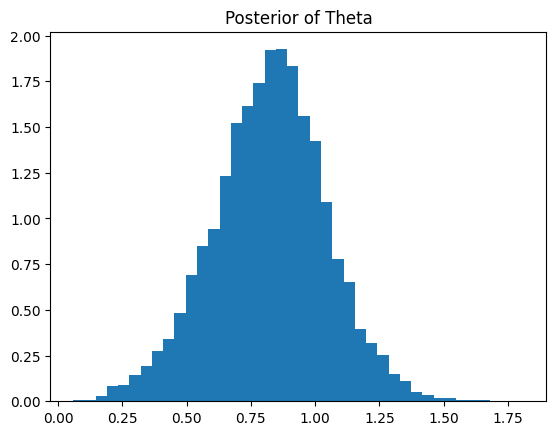

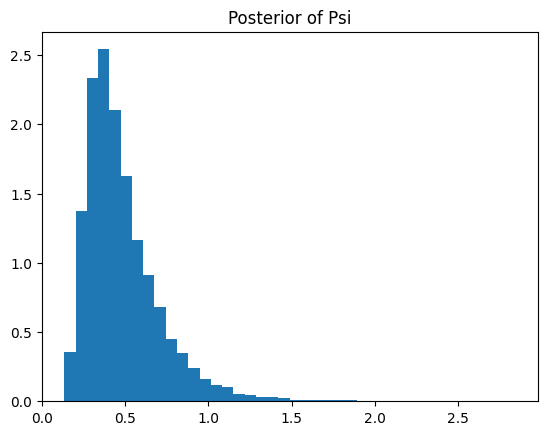

Theta mean: 0.8232071134951408
Theta 95% CI: [0.36685208 1.25501656]
Psi mean: 0.48348769385005363
Psi 95% CI: [0.20241623 1.0771714 ]


In [16]:
def mh_sampler(logpost, X, n_iter=20_000, step=0.3):
    xi, gamma = 0.0, 0.0   # starting point
    samples = []

    for t in range(n_iter):
        # propose
        xi_prop   = xi   + np.random.normal(0, step)
        gamma_prop = gamma + np.random.normal(0, step)

        # acceptance ratio
        logA = logpost(xi_prop, gamma_prop, X) - logpost(xi, gamma, X)
        if np.log(np.random.rand()) < logA:
            xi, gamma = xi_prop, gamma_prop

        samples.append((xi, gamma))

    return np.array(samples)


samples = mh_sampler(log_posterior_xi_gamma, X)
theta_samples = np.exp(samples[:,0])
psi_samples   = np.exp(samples[:,1])

plt.hist(theta_samples, bins=40, density=True)
plt.title("Posterior of Theta")
plt.show()

plt.hist(psi_samples, bins=40, density=True)
plt.title("Posterior of Psi")
plt.show()

theta_mean = np.mean(theta_samples)
theta_ci = np.percentile(theta_samples, [2.5, 97.5])

psi_mean = np.mean(psi_samples)
psi_ci = np.percentile(psi_samples, [2.5, 97.5])

print("Theta mean:", theta_mean)
print("Theta 95% CI:", theta_ci)
print("Psi mean:", psi_mean)
print("Psi 95% CI:", psi_ci)


Part 3, E

In [23]:
np.random.seed(42)

theta_true, psi_true = theta, psi
print("True Theta:", theta_true)
print("True Psi:", psi_true)

# run an experiment
def run_experiment(n, theta_true, psi_true, step=0.3, iters=20000):
    # 1. simulate data
    X = np.random.normal(theta_true, np.sqrt(psi_true), size=n)

    # 2. run MH
    samples = mh_sampler(log_posterior_xi_gamma, X, n_iter=iters, step=step)

    # 3. transform back
    theta_samples = np.exp(samples[:,0])
    psi_samples   = np.exp(samples[:,1])

    # 4. compute summaries
    theta_mean = np.mean(theta_samples)
    theta_ci   = np.percentile(theta_samples, [2.5, 97.5])

    psi_mean = np.mean(psi_samples)
    psi_ci   = np.percentile(psi_samples, [2.5, 97.5])

    return {
        "theta_samples": theta_samples,
        "psi_samples": psi_samples,
        "theta_mean": theta_mean,
        "theta_ci": theta_ci,
        "psi_mean": psi_mean,
        "psi_ci": psi_ci
    }


results_10   = run_experiment(10,   theta_true, psi_true)
results_100  = run_experiment(100,  theta_true, psi_true)
results_1000 = run_experiment(1000, theta_true, psi_true)


def print_summary(name, res):
    print(f"\n{name}")
    print("Theta mean:", res["theta_mean"])
    print("Theta 95% CI:", res["theta_ci"])
    print("Psi mean:", res["psi_mean"])
    print("Psi 95% CI:", res["psi_ci"])

print_summary("n = 10", results_10)
print_summary("n = 100", results_100)
print_summary("n = 1000", results_1000)


True Theta: 0.6969546573594286
True Psi: 0.6069558498886052

n = 10
Theta mean: 0.9404263177559867
Theta 95% CI: [0.50864784 1.33952603]
Psi mean: 0.4196902015439553
Psi 95% CI: [0.17341973 0.96601691]

n = 100
Theta mean: 0.6456741096450768
Theta 95% CI: [0.47297416 0.82124921]
Psi mean: 0.7772517889692877
Psi 95% CI: [0.59231739 1.03199419]

n = 1000
Theta mean: 0.7042872593603935
Theta 95% CI: [0.65962474 0.75178937]
Psi mean: 0.5667154475496384
Psi 95% CI: [0.51649076 0.61815835]


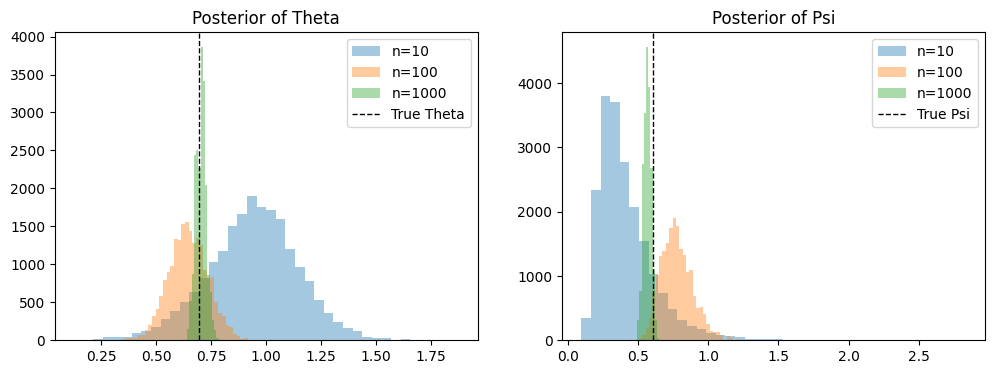

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(results_10["theta_samples"], bins=40, alpha=0.4, label="n=10")
plt.hist(results_100["theta_samples"], bins=40, alpha=0.4, label="n=100")
plt.hist(results_1000["theta_samples"], bins=40, alpha=0.4, label="n=1000")
plt.axvline(theta_true, color='k', linestyle='dashed', linewidth=1, label="True Theta")
plt.title("Posterior of Theta")
plt.legend()

plt.subplot(1,2,2)
plt.hist(results_10["psi_samples"], bins=40, alpha=0.4, label="n=10")
plt.hist(results_100["psi_samples"], bins=40, alpha=0.4, label="n=100")
plt.hist(results_1000["psi_samples"], bins=40, alpha=0.4, label="n=1000")
plt.axvline(psi_true, color='k', linestyle='dashed', linewidth=1, label="True Psi")
plt.title("Posterior of Psi")
plt.legend()

plt.show()


# Notes: Posterior becomes more concentrated as n increases, and posterior mean approaches the true values